## **Par MPOUAVOULI Rayde Prosperin**
## **Projet : Analyse technique et modélisation quantitative des marchés financiers avec Python**

#### **Objectifs du Chapitre**
##### - Comprendre le role des indicateurs dans la lecture des techniques
##### - Mettre en oeuvre les principaux indicateurs en python: RSI, MACD, OBV, A/D, CMF
##### - Visualiser les signaux de surchat, survente, accumulation et distribution
##### - Interpréter graphiquement les divergences entre les prix et volume
##### - créer script python d'analyse technique applicable à n'importe quel actif

In [18]:
#Installation des packages

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

In [4]:
# Téléchargement de la base de données de l'action Apple
apple= yf.download("AAPL", start="2020-01-01", end="2024-12-01")
apple.columns=apple.columns.droplevel("Ticker")
apple.dropna(inplace=True)
apple.tail()

C:\Users\Visiteur\AppData\Local\Temp\ipykernel_71884\1601814368.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple= yf.download("AAPL", start="2020-01-01", end="2024-12-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-11-22,229.056854,229.903854,227.253259,227.253259,38168300
2024-11-25,232.046249,232.424910,228.927332,230.641249,90152800
2024-11-26,234.228500,234.736706,232.504624,232.504624,45986200
2024-11-27,234.098969,234.856290,232.982935,233.640604,33498400
2024-11-29,236.490479,236.968776,233.142363,233.979388,28481400


### 1- **Calculer et interpréter le RSI**

##### Le RSI(Relative Strenght index) est un indicateur de momentum qui mesure la vitesse et l'amplitude des variations des prix.
##### Il oscille entre 0 et 100 et permet d'identifier des situations de :
##### - Surchat: RSI > 70
##### - Survente:RSI < 30

$$
RSI = 100 - \frac{100}{1 + RS}
$$


$$
RS = \frac{\text{moyenne des gains sur } n \text{ périodes}}{\text{moyenne des pertes sur } n \text{ périodes}}
$$


#### Interpretation
###### - **RSI > 70: actif potentiellement suracheté, attention à un repli**
###### - **RSI < 30: actif potentiellement vendu, attention à un rebond**

#### Le RSI est souvent utilisé avec une période de 14 jours

In [5]:
apple["diff"] =apple["Close"].diff()
apple.head()

Price,Close,High,Low,Open,Volume,diff
Date,,,,,,
2020-01-02,72.538513,72.598892,71.292304,71.545890,135480400,NaN
2020-01-03,71.833290,72.594055,71.608685,71.765667,146322800,-0.705223
2020-01-06,72.405678,72.444321,70.703012,70.954188,118387200,0.572388
2020-01-07,72.065155,72.671348,71.845377,72.415345,108872000,-0.340523
2020-01-08,73.224411,73.526303,71.768086,71.768086,132079200,1.159256


#### **On a un gain lorsque la diffrence est position et une perte lorsque la difference est negative**

In [6]:
# Séparer les gains et les pertes
apple['gain']= apple['diff'].apply(lambda x: x if x >0 else 0)
apple['loss'] =apple['diff'].apply(lambda x: -x if x < 0 else 0)

In [7]:
# Période du RSI
window =14

In [8]:
#Moyenne mobile simple sur 14 jours
apple['avg_gain'] =apple['gain'].rolling(window=window).mean()
apple['avg_loss'] =apple['loss'].rolling(window=window).mean()
apple.tail()

Price,Close,High,Low,Open,Volume,diff,gain,loss,avg_gain,avg_loss
Date,,,,,,,,,,
2024-11-22,229.056854,229.903854,227.253259,227.253259,38168300,1.345215,1.345215,0.000000,1.105591,0.528782
2024-11-25,232.046249,232.424910,228.927332,230.641249,90152800,2.989395,2.989395,0.000000,1.216738,0.528782
2024-11-26,234.228500,234.736706,232.504624,232.504624,45986200,2.182251,2.182251,0.000000,1.372613,0.476881
2024-11-27,234.098969,234.856290,232.982935,233.640604,33498400,-0.129532,0.000000,0.129532,1.034187,0.486133
2024-11-29,236.490479,236.968776,233.142363,233.979388,28481400,2.391510,2.391510,0.000000,1.205009,0.466916


In [9]:
# Calcul du RS (Relative strenght)
apple['RS'] = apple['avg_gain']/apple['avg_loss']
apple.tail(5)

Price,Close,High,Low,Open,Volume,diff,gain,loss,avg_gain,avg_loss,RS
Date,,,,,,,,,,,
2024-11-22,229.056854,229.903854,227.253259,227.253259,38168300,1.345215,1.345215,0.000000,1.105591,0.528782,2.090824
2024-11-25,232.046249,232.424910,228.927332,230.641249,90152800,2.989395,2.989395,0.000000,1.216738,0.528782,2.301018
2024-11-26,234.228500,234.736706,232.504624,232.504624,45986200,2.182251,2.182251,0.000000,1.372613,0.476881,2.878315
2024-11-27,234.098969,234.856290,232.982935,233.640604,33498400,-0.129532,0.000000,0.129532,1.034187,0.486133,2.127375
2024-11-29,236.490479,236.968776,233.142363,233.979388,28481400,2.391510,2.391510,0.000000,1.205009,0.466916,2.580786


In [15]:
# Calculer du RSI
apple['RSI'] = 100 - (100/(1 + apple['RS']))
apple['RSI'].describe()

count    1224.000000
mean       54.528833
std        16.938108
min         3.180367
25%        42.233207
50%        55.448168
75%        68.120237
max        93.242161
Name: RSI, dtype: float64

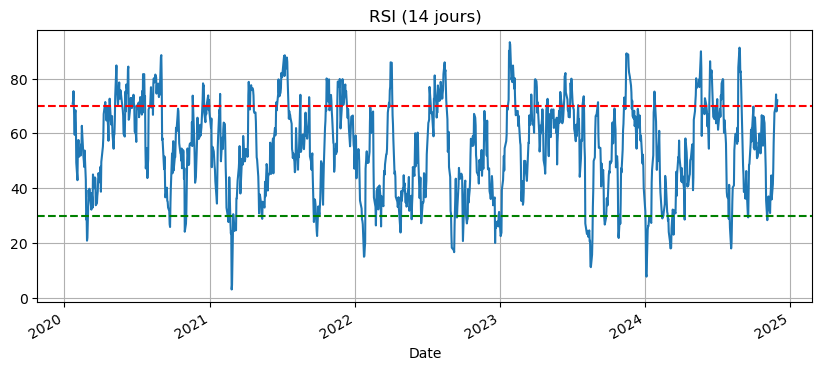

In [16]:
# Visualisation pour voir les période surchat et de survente
plt.figure(figsize=(10,4))
apple['RSI'].plot(title ='RSI (14 jours)')
plt.axhline(70, color='red', linestyle='--') #Situation de suchat
plt.axhline(30, color='green', linestyle='--') #Situation de survente
plt.grid()
plt.show()


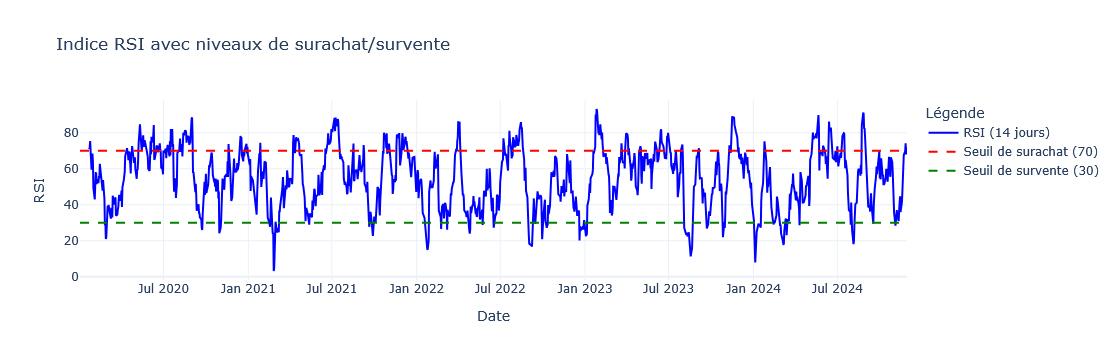

In [23]:
import plotly.graph_objects as go

fig = go.Figure()

# Courbe RSI
fig.add_trace(go.Scatter(x=apple.index, y=apple['RSI'], mode='lines', name='RSI (14 jours)', line=dict(color='blue')))

# Lignes horizontales : Surachat (70) et Survente (30)
fig.add_trace(go.Scatter(x=[apple.index.min(), apple.index.max()], y=[70, 70], mode='lines', name='Seuil de surachat (70)', line=dict(color='red', dash='dash')))
fig.add_trace(go.Scatter(x=[apple.index.min(), apple.index.max()], y=[30, 30], mode='lines', name='Seuil de survente (30)', line=dict(color='green', dash='dash')))

# Mise en page
fig.update_layout(title='Indice RSI avec niveaux de surachat/survente', xaxis_title='Date', yaxis_title='RSI', template='plotly_white', legend_title='Légende')
fig.show()

## 3- **Analyser la tendance avec le MACD**

##### Le MACD (Moving Average Convergence Divergence) est un indicateur technique très populaire qui permet de suivre la dynamique d’un actif. Il est basé sur la différence entre deux moyennes mobiles exponentielles (EMA), généralement à 12 et 26 périodes.

##### **À quoi sert le MACD** ?
##### - Identifier les changements de dynamique du marché
##### -Repérer les points d’entrée et de sortie
##### -Visualiser le momentum (accélération/décélération d’une tendance)
##### -Confirmer ou invalider un signal donné par le prix seul

### **Composantes du MACD**
##### -**EMA 12** : moyenne mobile exponentielle des 12 dernières clôtures → représente le prix moyen à court terme
##### -**EMA 26** : moyenne mobile exponentielle des 26 dernières clôtures → représente le prix moyen à long terme
##### -**MACD Line** : différence entre EMA 12 et EMA 26 → met en évidence les divergences de momentum
##### -**Signal Line** : EMA de la MACD sur 9 périodes → permet de lisser les variations de la MACD
##### -**Histogramme** : différence entre MACD et sa ligne Signal → reflète la force du momentum

##### Le MACD est défini comme :
$$
\text{MACD}(t) = EMA_{12}(t) - EMA_{26}(t)
$$

##### Ensuite, on calcule une ligne de signal :
$$
\text{Signal}(t) = EMA_{9}(\text{MACD}(t))
$$
##### Et l’histogramme MACD (différence entre MACD et sa ligne de signal) :
$$
\text{Histogramme}(t) = \text{MACD}(t) - \text{Signal}(t)
$$
### **Interprétation** :
##### -Lorsque MACD croise au-dessus de la ligne de signal(signal d’achat)
##### -Lorsque MACD croise en dessous (signal de vente)
##### -L’histogramme permet de visualiser le momentum (positif ou négatif)
##### Le MACD est un outil de suivi de tendance : il fonctionne mieux dans des marchés en tendance (haussière ou baissière) que dans les phases de range.

In [25]:
apple['EMA_12'] = apple['Close'].ewm(span=12, adjust=False).mean()   
apple['EMA_26'] = apple['Close'].ewm(span=26, adjust=False).mean()

In [26]:
apple['MACD'] = apple['EMA_12'] - apple['EMA_26']
apple['Signal'] = apple['MACD'].ewm(span=9, adjust=False).mean()
apple.head()

Price,Close,High,Low,Open,Volume,diff,gain,loss,avg_gain,avg_loss,RS,OBV,RSI,EMA_12,EMA_26,MACD,Signal
Date,,,,,,,,,,,,,,,,,
2020-01-02,72.538513,72.598892,71.292304,71.545890,135480400,NaN,0.000000,0.000000,NaN,NaN,NaN,0,NaN,72.538513,72.538513,0.000000,0.000000
2020-01-03,71.833290,72.594055,71.608685,71.765667,146322800,-0.705223,0.000000,0.705223,NaN,NaN,NaN,-146322800,NaN,72.430017,72.486274,-0.056257,-0.011251
2020-01-06,72.405678,72.444321,70.703012,70.954188,118387200,0.572388,0.572388,0.000000,NaN,NaN,NaN,-27935600,NaN,72.426273,72.480304,-0.054032,-0.019807
2020-01-07,72.065155,72.671348,71.845377,72.415345,108872000,-0.340523,0.000000,0.340523,NaN,NaN,NaN,-136807600,NaN,72.370716,72.449553,-0.078836,-0.031613
2020-01-08,73.224411,73.526303,71.768086,71.768086,132079200,1.159256,1.159256,0.000000,NaN,NaN,NaN,-4728400,NaN,72.502054,72.506949,-0.004896,-0.026270


In [27]:
apple['Histogram'] = apple['MACD'] - apple['Signal'] 
apple.head()

Price,Close,High,Low,Open,Volume,diff,gain,loss,avg_gain,avg_loss,RS,OBV,RSI,EMA_12,EMA_26,MACD,Signal,Histogram
Date,,,,,,,,,,,,,,,,,,
2020-01-02,72.538513,72.598892,71.292304,71.545890,135480400,NaN,0.000000,0.000000,NaN,NaN,NaN,0,NaN,72.538513,72.538513,0.000000,0.000000,0.000000
2020-01-03,71.833290,72.594055,71.608685,71.765667,146322800,-0.705223,0.000000,0.705223,NaN,NaN,NaN,-146322800,NaN,72.430017,72.486274,-0.056257,-0.011251,-0.045006
2020-01-06,72.405678,72.444321,70.703012,70.954188,118387200,0.572388,0.572388,0.000000,NaN,NaN,NaN,-27935600,NaN,72.426273,72.480304,-0.054032,-0.019807,-0.034224
2020-01-07,72.065155,72.671348,71.845377,72.415345,108872000,-0.340523,0.000000,0.340523,NaN,NaN,NaN,-136807600,NaN,72.370716,72.449553,-0.078836,-0.031613,-0.047223
2020-01-08,73.224411,73.526303,71.768086,71.768086,132079200,1.159256,1.159256,0.000000,NaN,NaN,NaN,-4728400,NaN,72.502054,72.506949,-0.004896,-0.026270,0.021374


C:\Users\Visiteur\AppData\Local\Temp\ipykernel_71884\1850006573.py:34: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



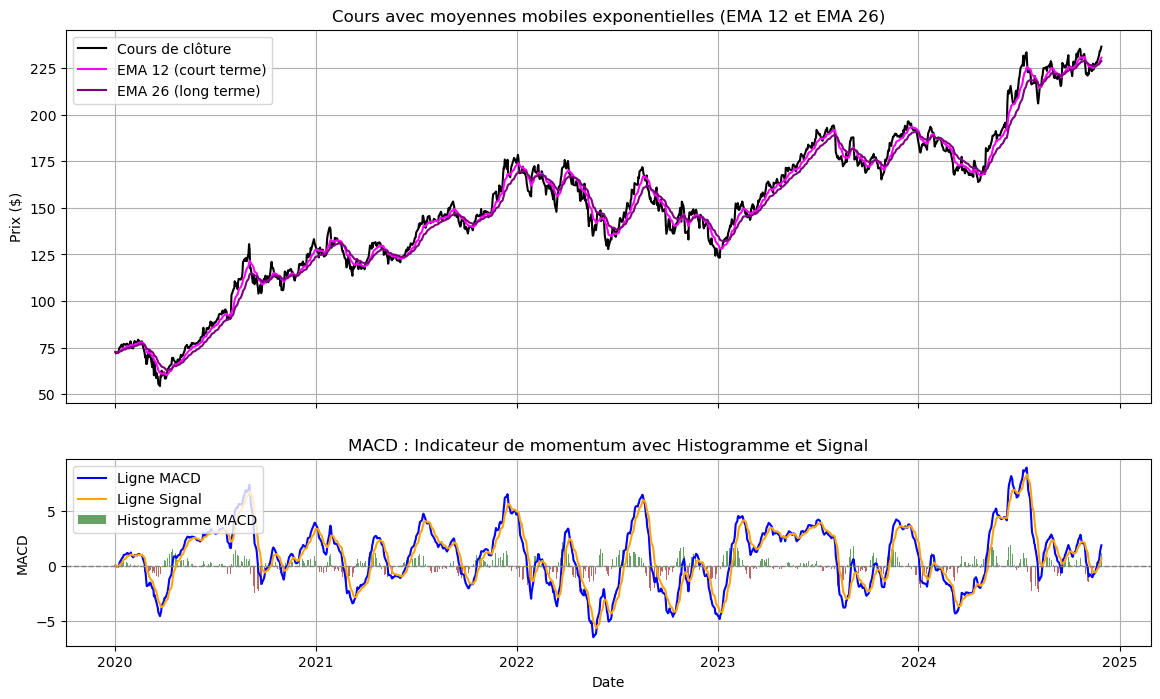

In [28]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# Couleurs personnalisées pour l'histogramme
colors = ['darkgreen' if val >= 0 else 'darkred' for val in apple['Histogram']]

# Grille avec 2 sous-graphiques
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.2)


# ----- 1. Graphique des prix + EMA -----
ax1 = plt.subplot(gs[0])
ax1.plot(apple['Close'], label='Cours de clôture', color='black')
ax1.plot(apple['EMA_12'], label='EMA 12 (court terme)', color='magenta')
ax1.plot(apple['EMA_26'], label='EMA 26 (long terme)', color='purple')
ax1.set_title("Cours avec moyennes mobiles exponentielles (EMA 12 et EMA 26)")
ax1.set_ylabel("Prix ($)")
ax1.legend(loc='upper left')
ax1.grid(True)

# ----- 2. Graphique MACD -----
ax2 = plt.subplot(gs[1], sharex=ax1)
ax2.bar(apple.index, apple['Histogram'], color=colors, alpha=0.6, label='Histogramme MACD')
ax2.plot(apple['MACD'], label='Ligne MACD', color='blue')
ax2.plot(apple['Signal'], label='Ligne Signal', color='orange')
ax2.axhline(0, color='gray', linewidth=1, linestyle='--')
ax2.set_title("MACD : Indicateur de momentum avec Histogramme et Signal")
ax2.set_ylabel("MACD")
ax2.legend(loc='upper left')
ax2.grid(True)

plt.setp(ax1.get_xticklabels(), visible=False)
plt.xlabel("Date")
plt.tight_layout()
plt.show()

### 4- **Utiliser OBV(On-Balance Volume) pour suivre l'accumulation**

##### c'est un indicateur technique qu permet de mesurer la **pression d'achat det de vente** à travers les volumes. Il sert à détecter les phases d'accumulation(achats discrets) ou de distribution(ventes dissimulées) avant un mouvement de prix négatif.
##### Le OBV cumule les volumes de la manière suivante:
##### - Si le **cours de cloture** d'aujourd'hui est supérieur à celui d'hier on ajoute le volume du jour au OBV
##### - Si le cours de cloture est inférieur on soustrait le volume
##### - Si le cours est **inchangé** le OBV reste identique

#### **Formule du OBV**
$$
OBV_t = OBV_{t-1} + 
\begin{cases} 
V_t, & \text{si } P_t > P_{t-1} \\[2mm]
-V_t, & \text{si } P_t < P_{t-1} \\[1mm]
0, & \text{si } P_t = P_{t-1}
\end{cases}
$$

#### **Tendance OBV**
##### OBV en **Hausse** accumulation (les acheteurs prennent position discrètement)
##### OBV en **Baisse) distribution( les vendeurs sortent discrètement)

#### **Divergence OBV/Prix**
##### - Si le **prix stagne ou baisse**, mais que l'OBV monte ce qui entraine **signal haussier caché**(accumulation)
##### - Si le **Prix monte**, mais que l'OBV baisse **signal baissier caché**(distribution)

#### **Confirmation de tendance**
##### - si l'OBV suit et renforce le mouvement du prix la tendance est **saine**
##### - Au cas contraire possible de retournement à venir

In [20]:
def calculate_obv(data):
    obv = [0]  # initialiser avec 0
    close = data['Close'].values
    volume = data['Volume'].values

    for i in range(1, len(data)):
        if close[i] > close[i - 1]:
            obv.append(obv[-1] + volume[i])
        elif close[i] < close[i - 1]:
            obv.append(obv[-1] - volume[i])
        else:
            obv.append(obv[-1])

    data = data.copy()  # créer une copie pour éviter les effets de bord
    data['OBV'] = obv
    return data

# Appel de la fonction après l'avoir définie
apple = calculate_obv(apple)
apple.head()


Price,Close,High,Low,Open,Volume,diff,gain,loss,avg_gain,avg_loss,RS,OBV,RSI
Date,,,,,,,,,,,,,
2020-01-02,72.538513,72.598892,71.292304,71.545890,135480400,NaN,0.000000,0.000000,NaN,NaN,NaN,0,NaN
2020-01-03,71.833290,72.594055,71.608685,71.765667,146322800,-0.705223,0.000000,0.705223,NaN,NaN,NaN,-146322800,NaN
2020-01-06,72.405678,72.444321,70.703012,70.954188,118387200,0.572388,0.572388,0.000000,NaN,NaN,NaN,-27935600,NaN
2020-01-07,72.065155,72.671348,71.845377,72.415345,108872000,-0.340523,0.000000,0.340523,NaN,NaN,NaN,-136807600,NaN
2020-01-08,73.224411,73.526303,71.768086,71.768086,132079200,1.159256,1.159256,0.000000,NaN,NaN,NaN,-4728400,NaN


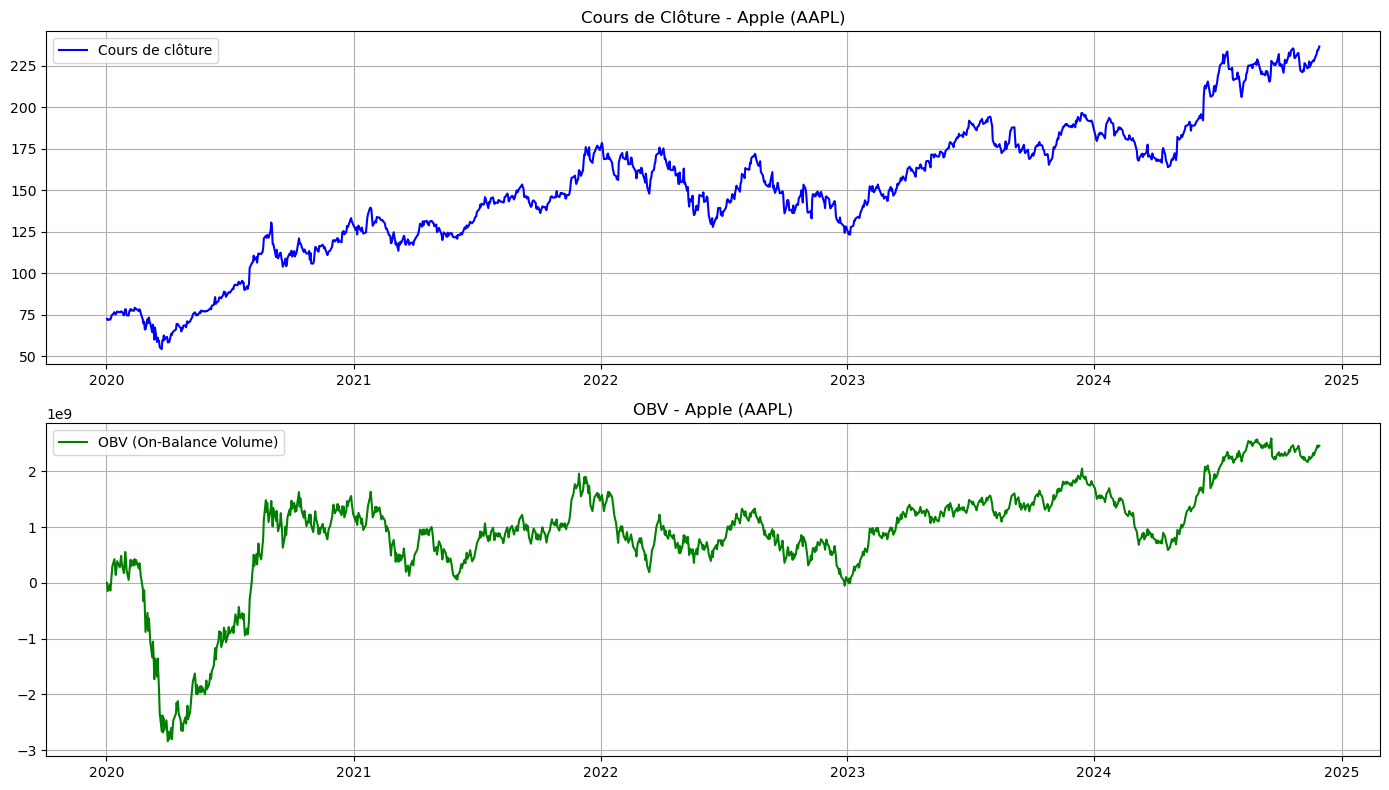

In [21]:
# Affichage graphique
plt.figure(figsize=(14, 8))

# Cours de clôture
plt.subplot(2, 1, 1)
plt.plot(apple['Close'], label='Cours de clôture', color='blue')
plt.title("Cours de Clôture - Apple (AAPL)")
plt.legend()
plt.grid()

# OBV
plt.subplot(2, 1, 2)
plt.plot(apple['OBV'], label='OBV (On-Balance Volume)', color='green')
plt.title("OBV - Apple (AAPL)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


### 5- **Etudier les indicateurs d'accumulation/distribution(A/D Line)**

##### L'indicateur A/D est un outil d'analyse technique qui mesure la **pression acheteuse ou vendeuse** en combinant pix et volume
##### Il sert à détecter les phases d'accumultion(achats discrets) ou de distribution(ventes discretes), souvent avant que le prix ne bouge significativement. **Ct (Prix de cloture)**, **Lt( Plus bas du jour)**, **Ht(plus haut du jour)**, **MFV(Volume pondéré par le CLV)**

$$
CLV_t = \frac{(C_t - L_t) - (H_t - C_t)}{H_t - L_t} = \frac{2C_t - H_t - L_t}{H_t - L_t}
$$

$$
MFV_t = CLV_t \times V_t
$$

$$
AD_t = AD_(t-1) + MFV_t
$$

| **Clôture (C)** | **CLV (Close Location Value)** | **Impact sur MFV (C × Volume)** | **Impact sur AD (Accumulation/Distribution)** |
|-----------------|-------------------------------|---------------------------------|---------------------------------------------|
| C ≈ Haut (proche du H) | CLV ≈ +1 | MFV élevé et positif | AD augmente → accumulation |
| C ≈ Milieu (proche de (H+L)/2) | CLV ≈ 0 | MFV proche de 0 | AD stable → flux neutre |
| C ≈ Bas (proche du L) | CLV ≈ -1 | MFV négatif | AD diminue → distribution |


In [31]:
plot_data = apple.copy()  #Modifier la base de données sans garder le lien avec la base précédente
plot_data = plot_data.reset_index()

In [32]:
# Calcul du CLV
clv = ((plot_data['Close'] - plot_data['Low']) - (plot_data['High'] - plot_data['Close'])) / (plot_data['High'] - plot_data['Low'])
clv = clv.fillna(0)

In [33]:
# Calcul du MFV
mfv = clv * plot_data['Volume']

In [34]:
# Calcul de l'A/D
ad = mfv.cumsum()

In [35]:
# Ajout au DataFrame
plot_data['CLV'] = clv
plot_data['MFV'] = mfv
plot_data['AD'] = ad

plot_data.head()

Price,Date,Close,High,Low,Open,Volume,diff,gain,loss,avg_gain,...,OBV,RSI,EMA_12,EMA_26,MACD,Signal,Histogram,CLV,MFV,AD
0,2020-01-02,72.538513,72.598892,71.292304,71.545890,135480400,NaN,0.000000,0.000000,NaN,...,0,NaN,72.538513,72.538513,0.000000,0.000000,0.000000,0.907579,1.229591e+08,1.229591e+08
1,2020-01-03,71.833290,72.594055,71.608685,71.765667,146322800,-0.705223,0.000000,0.705223,NaN,...,-146322800,NaN,72.430017,72.486274,-0.056257,-0.011251,-0.045006,-0.544120,-7.961712e+07,4.334199e+07
2,2020-01-06,72.405678,72.444321,70.703012,70.954188,118387200,0.572388,0.572388,0.000000,NaN,...,-27935600,NaN,72.426273,72.480304,-0.054032,-0.019807,-0.034224,0.955616,1.131327e+08,1.564747e+08
3,2020-01-07,72.065155,72.671348,71.845377,72.415345,108872000,-0.340523,0.000000,0.340523,NaN,...,-136807600,NaN,72.370716,72.449553,-0.078836,-0.031613,-0.047223,-0.467831,-5.093375e+07,1.055410e+08
4,2020-01-08,73.224411,73.526303,71.768086,71.768086,132079200,1.159256,1.159256,0.000000,NaN,...,-4728400,NaN,72.502054,72.506949,-0.004896,-0.026270,0.021374,0.656593,8.672232e+07,1.922633e+08


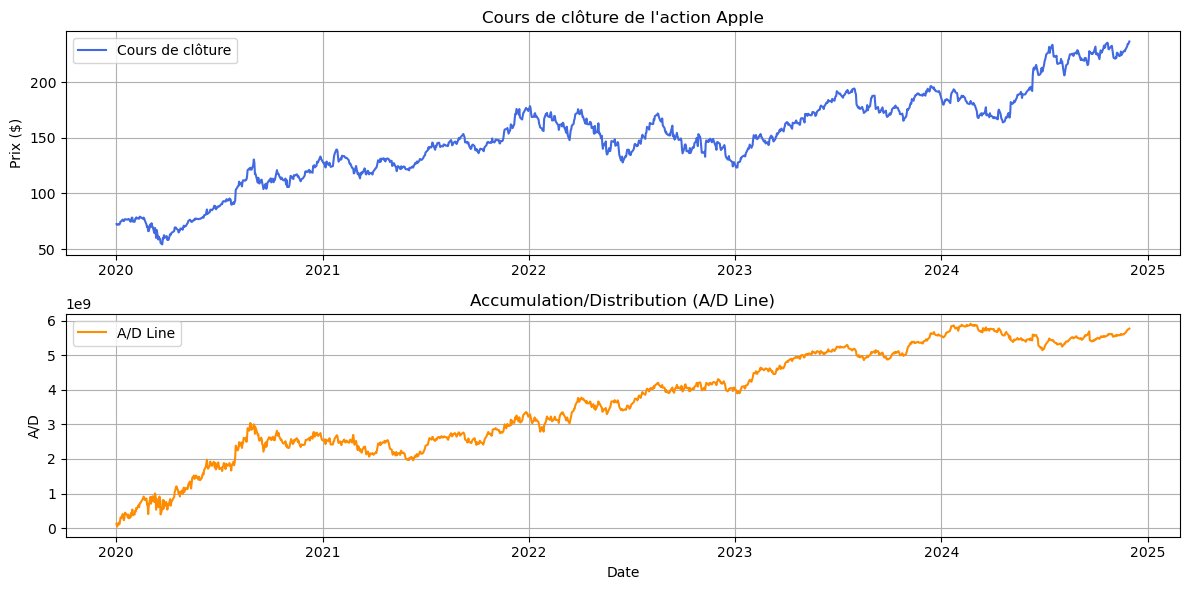

In [36]:
import matplotlib.pyplot as plt
# Taille globale de la figure
plt.figure(figsize=(12, 6))

# 1. Cours de clôture
plt.subplot(2, 1, 1)
plt.plot(plot_data['Date'], plot_data['Close'], label='Cours de clôture', color='royalblue')
plt.title("Cours de clôture de l'action Apple")
plt.ylabel('Prix ($)')
plt.grid(True)
plt.legend()

# 2. Ligne A/D
plt.subplot(2, 1, 2)
plt.plot(plot_data['Date'], plot_data['AD'], label='A/D Line', color='darkorange')
plt.title("Accumulation/Distribution (A/D Line)")
plt.xlabel('Date')
plt.ylabel('A/D')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()